In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optimizer
from torch.utils.data import Dataset , DataLoader , random_split ,Subset
from torchvision import transforms , datasets
from matplotlib import pyplot as plt
import numpy as np
    

import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report

In [4]:
torch.manual_seed(42)


In [5]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 4060 Ti


In [6]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])


data = datasets.FashionMNIST(
    root="./data",
    train= True ,
    download=True ,
    transform=transform
)
test = datasets.FashionMNIST(
    root="./data",
    train= False ,
    download=True ,
    transform=transform
)

train_size = int(0.8 * len(data))
val_size = int(0.2 * len(data))
train_indices , val_indices = random_split(data , [train_size , val_size])

x, y = data[0]
print(x.shape , y)


torch.Size([3, 224, 224]) 9


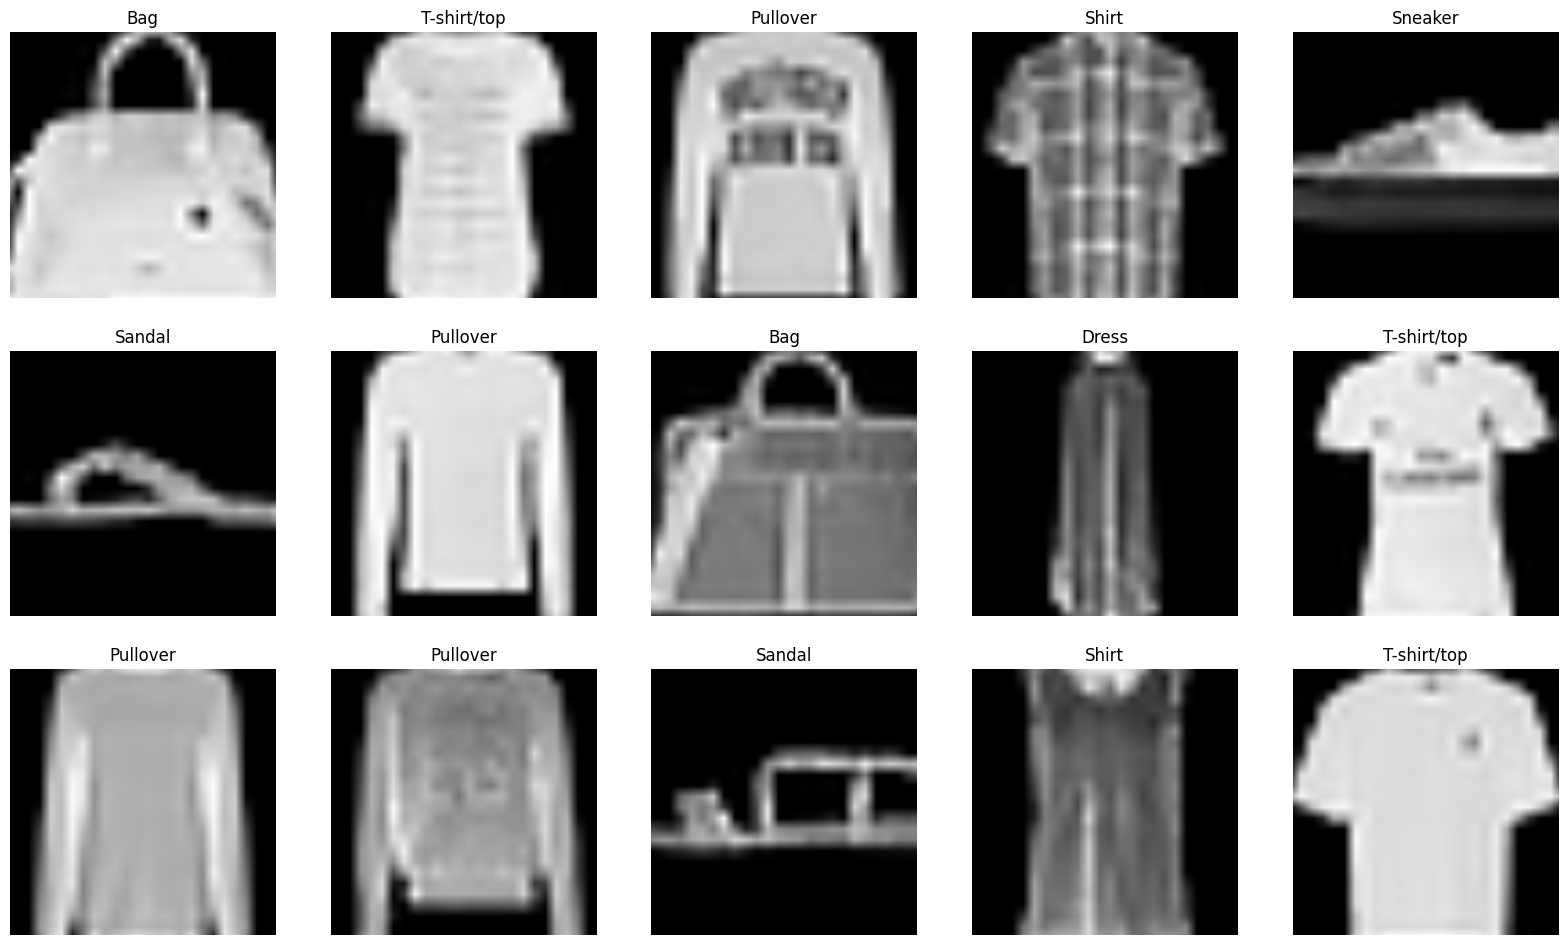

In [7]:
import random

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

def unnormalize(img):
    img = img.permute(1, 2, 0)
    img = std * img + mean
    img = torch.clamp(img, 0, 1)
    return img

def show_images(data , number_images=15):
    classes = data.classes
    plt.figure(figsize=(20,20))
    for i in range(number_images):
        plt.subplot(5 , 5 , i+1)
        idx = random.randint(0 , len(data))
        x , y = data[idx]
        # x = x.permute(1,2,0)
        plt.imshow(unnormalize(x))
        plt.axis("off")
        plt.title(classes[y])
    plt.show()
show_images(data)

In [8]:
train_data = Subset(data , train_indices.indices)
val_data = Subset(data , val_indices.indices)
test_data = test

In [9]:
print("Train shapes")
idx = 0
x1 , y1 = train_data[idx]
print(x1.shape , y1)
print("Val shapes")
x2 , y2 = val_data[idx]
print(x2.shape , y2)
print("Test shapes")
x3 , y3 = test_data[idx]
print(x3.shape , y3)

Train shapes
torch.Size([3, 224, 224]) 9
Val shapes
torch.Size([3, 224, 224]) 6
Test shapes
torch.Size([3, 224, 224]) 9


In [10]:
from scipy.sparse import base
class FashionMNIST(Dataset):
    def __init__(self , base_dataset):
        self.dataset = base_dataset
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, index):
        X , y = self.dataset[index]
        return X , y




In [11]:
classes = len(data.targets)
train_dataset = FashionMNIST(train_data)
val_dataset = FashionMNIST(val_data)
test_dataset = FashionMNIST(test_data)

In [12]:
idx = random.randint(0 , len(train_dataset))
x , y = train_dataset[idx]
print(x.shape , y , len(train_data))

torch.Size([3, 224, 224]) 5 48000


In [13]:
x[0] # first layer of a image

tensor([[-2.1179, -2.1179, -2.1179,  ..., -2.1008, -2.1008, -2.1008],
        [-2.1179, -2.1179, -2.1179,  ..., -2.1008, -2.1008, -2.1008],
        [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
        ...,
        [ 0.1597,  0.3823,  0.5878,  ..., -0.8507, -0.9020, -0.9534],
        [-0.1143,  0.1254,  0.3481,  ..., -0.7479, -0.8164, -0.8507],
        [-0.3712, -0.1143,  0.1254,  ..., -0.6623, -0.7308, -0.7650]])

# Main Code

In [14]:
import torchvision.models as model
vgg16 = model.vgg16(pretrained=True)

C:\Users\abdur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\abdur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [16]:
for param in vgg16.features.parameters():
    param.requires_grad = False

In [17]:
# vgg16.classifier = nn.Sequential(
#     nn.Linear(in_features=25088 , out_features=4096 , bias=True),
#     nn.ReLU(inplace=True),
#     nn.Dropout(p=0.5),
#     nn.Linear(in_features=4096 , out_features=4096 , bias=True),
#     nn.ReLU(inplace=True),
#     nn.Dropout(p=0.5),
#     nn.Linear(in_features=4096 , out_features=10 , bias=True)
# )
vgg16.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(25088, 128),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(128 , 64),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(64 , 32),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(32 , 16),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(16 , 10)

        )

In [18]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [27]:
class MainExecution():
    def __init__(self, X , num_classes, train_dataset , val_dataset , test_dataset, batch_size , lr):

        self.train_batch = DataLoader(train_dataset , batch_size=batch_size , shuffle=True)
        self.val_batch = DataLoader(val_dataset , batch_size=batch_size , shuffle=False)
        self.test_batch = DataLoader(test_dataset , batch_size=batch_size , shuffle=False)

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = vgg16.to(self.device)
        self.loss_fn = nn.CrossEntropyLoss()
        self.optimizer = optimizer.Adam(self.model.classifier.parameters() , lr , weight_decay=1e-5)
        self.scheduler = optimizer.lr_scheduler.StepLR(self.optimizer , step_size=10 , gamma=0.1)

        self.train_losses = None
        self.train_accuracies = None
        self.val_losses = None
        self.val_accuracies = None

    def get_model_dataloader(self):
        return self.model , self.test_batch

    def caculate_accuracy(self, y_pred , y_true):
        y_pred = torch.argmax(y_pred , dim=1)
        # y_true = torch.argmax(y_true , dim=1)
        return torch.sum(y_pred == y_true).item() / len(y_true)

    def validate(self, test=False):
        data_loader = self.val_batch
        if test:
            data_loader = self.test_batch
        self.model.eval()
        total_loss = 0
        total_accuracy = 0
        with torch.no_grad():
            for X, y in data_loader:
                X, y = X.to(self.device), y.to(self.device)
                y_pred = self.model(X)

                loss = self.loss_fn(y_pred, y)
                total_loss += loss.item()
                total_accuracy += self.caculate_accuracy(y_pred, y)

        total_loss /= len(data_loader)
        total_accuracy /= len(data_loader)
        return total_loss, total_accuracy

    def plot_graphs(self):
        total_epochs = len(self.val_losses)
        if total_epochs == 0:
            print("No data to plot.")
            return
        epochs = np.arange(0 , total_epochs, 1)

        plt.figure(figsize=(14,6))

        plt.subplot(1,2,1)
        plt.plot(epochs , self.val_losses , label="Validation Loss" , color="cyan")
        plt.plot(epochs , self.train_losses , label="Train Loss" , color="orange")
        plt.title("Loss vs Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()

        plt.subplot(1,2,2)
        plt.plot(epochs , self.val_accuracies , label="Validation Accuracy" , color="red")
        plt.plot(epochs , self.train_accuracies , label="Train Accuracy" , color="orange")
        plt.title("Accuracy vs Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.legend()

        plt.show()




    def train(self , num_epoch , show=True):
        train_losses = []
        train_accuracies = []
        val_losses = []
        val_accuracies = []

        self.model.train()
        for epoch in range(num_epoch):
            train_loss = 0
            train_accuracy = 0
            for X , y in self.train_batch:
                X , y = X.to(self.device) , y.to(self.device)
                y_pred = self.model(X)
                loss = self.loss_fn(y_pred , y)


                train_loss += loss.item()
                train_accuracy += self.caculate_accuracy(y_pred , y)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

            train_loss /= len(self.train_batch)
            train_accuracy /= len(self.train_batch)
            val_loss , val_accuracy = self.validate()

            if show:
                print(f"{epoch+1}/{num_epoch} -> train_loss : {train_loss:.4f} , val_loss : {val_loss:.4f} , train acc {train_accuracy:.4f} , val acc {val_accuracy:.4f}")

            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            val_losses.append(val_loss)
            val_accuracies.append(val_accuracy)
            self.scheduler.step()

        self.train_losses = train_losses
        self.train_accuracies = train_accuracies
        self.val_losses = val_losses
        self.val_accuracies = val_accuracies

        return train_losses , train_accuracies , val_losses , val_accuracies


def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            # labels = torch.argmax(labels, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - FashionMNIST")
    plt.show()

    print("--"*40)
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))
    class_accuracy = cm.diagonal() / cm.sum(axis=1)

    print("Per-Class Accuracy:")
    for idx, acc in enumerate(class_accuracy):
        print(f"{classes[idx]}: {acc*100:.2f}%")
    overall_acc = np.sum(cm.diagonal()) / np.sum(cm)
    print(f"Overall Accuracy: {overall_acc*100:.2f}%")






1/10 -> train_loss : 2.0169 , val_loss : 1.7077 , train acc 0.2468 , val acc 0.5012
2/10 -> train_loss : 0.9512 , val_loss : 0.4906 , train acc 0.6334 , val acc 0.8151
3/10 -> train_loss : 0.2818 , val_loss : 0.2603 , train acc 0.9112 , val acc 0.9090
4/10 -> train_loss : 0.1901 , val_loss : 0.2514 , train acc 0.9353 , val acc 0.9108
5/10 -> train_loss : 0.1487 , val_loss : 0.2304 , train acc 0.9509 , val acc 0.9185
6/10 -> train_loss : 0.1156 , val_loss : 0.2319 , train acc 0.9636 , val acc 0.9205
7/10 -> train_loss : 0.0895 , val_loss : 0.2340 , train acc 0.9726 , val acc 0.9211
8/10 -> train_loss : 0.0675 , val_loss : 0.2398 , train acc 0.9817 , val acc 0.9213
9/10 -> train_loss : 0.0496 , val_loss : 0.2421 , train acc 0.9883 , val acc 0.9210
10/10 -> train_loss : 0.0355 , val_loss : 0.2539 , train acc 0.9928 , val acc 0.9207
--------------------------------------------------------------------------------
Loss Graphs
------------------------------------------------------------------

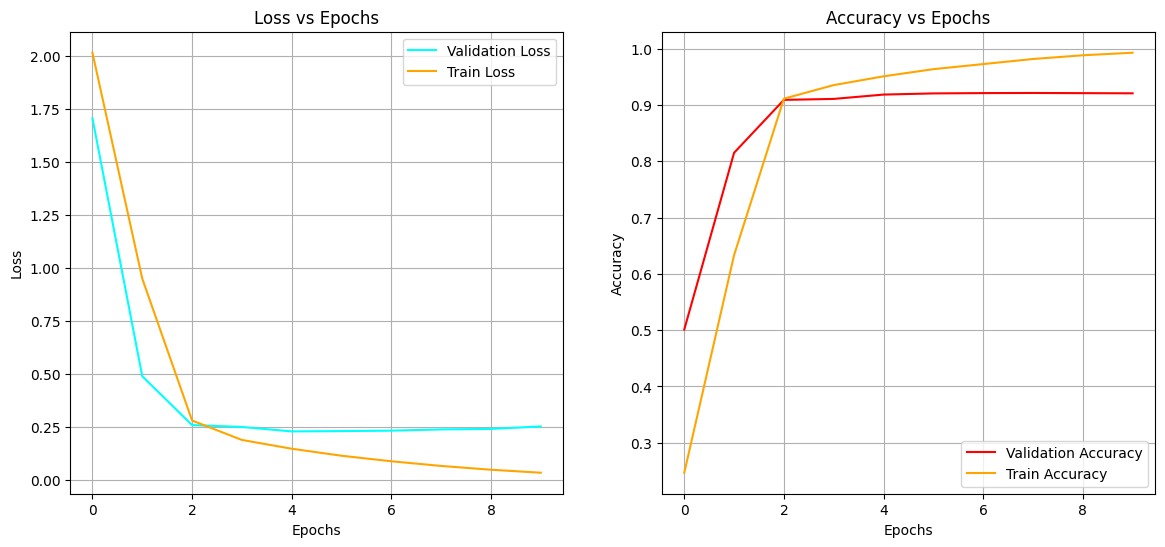

--------------------------------------------------------------------------------
Test Evaluation
--------------------------------------------------------------------------------
Test Loss : 0.2791 , Test Accuracy : 0.9198
--------------------------------------------------------------------------------
Confusion Matrix and Classification Report
--------------------------------------------------------------------------------


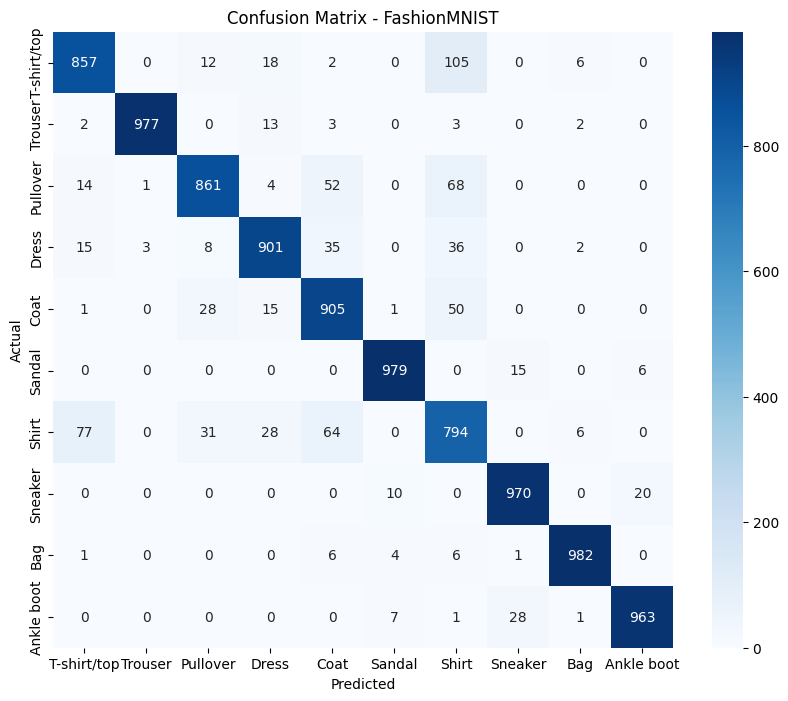

--------------------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.89      0.86      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.92      0.86      0.89      1000
       Dress       0.92      0.90      0.91      1000
        Coat       0.85      0.91      0.88      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.75      0.79      0.77      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Per-Class Accuracy:
T-shirt/top: 85.70%
Trouser: 97.70%
Pullover: 86.10%
Dress: 90.10%
Coat: 90.50%
Sandal: 97.90%
Shirt: 79.40%
Sneaker:

In [29]:
# (self, X , num_classes, train_dataset , val_dataset , test_dataset, batch_size , lr)
model = MainExecution(train_data , classes , train_dataset , val_dataset , test_dataset , 128 , 0.0001)
train_losses , train_accuracies , val_losses , val_accuracies = model.train(10)
print("--"*40)
print("Loss Graphs")
print("--"*40)
model.plot_graphs()
print("--"*40)
print("Test Evaluation")
print("--"*40)
test_loss , test_accuracy = model.validate(test=True)
print(f"Test Loss : {test_loss:.4f} , Test Accuracy : {test_accuracy:.4f}")
print("--"*40)
print("Confusion Matrix and Classification Report")
print("--"*40)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ , test_batches = model.get_model_dataloader()
evaluate_model(model_, test_batches, device)
print("--"*40)
print("End of Execution")